<div class="alert alert-info" role="alert" style="padding:20px; margin-bottom:16px;">
  <div style="text-align:center;">
    <h1 style="margin:0;">Exploratory Data Analysis</h1>
    <div style="font-size:18px; margin-top:4px;">Amazing International Airlines Inc.</div>
    <div style="font-size:18px; margin-top:4px;">Clustering - Value Based</div>
    <hr style="margin:12px auto; width:220px;">
    <div style="font-size:14px; color:#6c757d;">Group 92 • Notebook • 2025/2026</div>
  </div>
</div>


This Project was done by:


Student Name    -   Mehmet Karaca;
student id      -   20250344;
contact email   -   20250344@novaims.unl.pt

Student Name    -   Duarte Gomes;
student id      -   20250017;
contact email   -   20250017@novaims.unl.pt

Student Name    -   Esra Salhi
student id      -   20250537
contact email   -   20250537@novaims.unl.pt

## Table of Contents



Add some contents here



# 1 Introduction <a id="introduction"></a>


## 1.1. Importing Libraries <a id="importing-libraries"></a>


In [1]:
# --- Standard Imports
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib
import math
import matplotlib as mpl
from cycler import cycler
import geopandas as gpd
from matplotlib.lines import Line2D
from sklearn.impute import KNNImputer
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.base import clone
from scipy.cluster.hierarchy import dendrogram, linkage



In [2]:
# Plot style configuration (unified look)
# Keeps logic intact; only global appearance defaults are set.

# Accessible, consistent palette
_palette = sns.color_palette("Set1", 10)
_palette_hex = _palette.as_hex()

# Seaborn / Matplotlib defaults
sns.set_theme(style="whitegrid", context="notebook", palette=_palette)
mpl.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#333333',
    'axes.titleweight': 'semibold',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.grid': True,
    'grid.color': '#EAEAEA',
    'grid.linestyle': '-',
    'grid.alpha': 0.6,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.borderpad': 0.4,
    'legend.loc': 'best',
    'lines.linewidth': 2.0,
    'axes.prop_cycle': cycler('color', _palette_hex),
})


def make_palette_map(categories, palette_name="Set1", n_colors=None, as_hex=False):
    """
    Simple: returns (palette_map, palette_list).
    - categories: iterable (keeps first-seen order, coerces to str)
    - palette_name: seaborn palette name
    - n_colors: optional override (defaults to max(len(categories), 3))
    - as_hex: if True, return palette_map with hex strings
    """
    cats = [str(c) for c in dict.fromkeys(categories)]          # unique keep-order
    n_colors = n_colors or max(len(cats), 3)
    palette = sns.color_palette(palette_name, n_colors)
    palette_map = {cat: palette[i % len(palette)] for i, cat in enumerate(cats)}
    if as_hex:
        return {k: matplotlib.colors.to_hex(v) for k, v in palette_map.items()}, palette
    return palette_map, palette



# Plotly defaults (to align with seaborn/matplotlib)
px.defaults.template = 'plotly_white'
px.defaults.color_discrete_sequence = _palette_hex
px.defaults.color_continuous_scale = 'Cividis'
px.defaults.width = 900
px.defaults.height = 500


## 1.2. Loading and Reading Data <a id="loading-and-reading-data"></a>

In [3]:
# directory with raw CSV files
data_dir = Path("../data/cleanAndFeatureEngineered")

# list all CSV files
csv_files = list(data_dir.glob("*.csv"))
print(f"Found CSV files: {[f.name for f in csv_files]}")


Found CSV files: ['DM_AIAI_FlightsDB_Cleaned_Featured.csv', 'DM_AIAI_CustomerDB_Cleaned_Featured.csv']


In [4]:
# specify the files we want to load

customers_file = data_dir / "DM_AIAI_CustomerDB_Cleaned_Featured.csv"
flights_file   = data_dir / "DM_AIAI_FlightsDB_Cleaned_Featured.csv"

# load them with pandas
customers = pd.read_csv(customers_file)
flights   = pd.read_csv(flights_file)

print("Customers shape:", customers.shape)
print("Flights shape:", flights.shape)

Customers shape: (16375, 32)
Flights shape: (596664, 11)


## 1.3. Brief Preliminary Analysis <a id="brief-preliminary-analysis"></a>

In [5]:
customers.columns

Index(['Loyalty#', 'First Name', 'Last Name', 'Customer Name', 'Country',
       'Province or State', 'City', 'Latitude', 'Longitude', 'Postal code',
       'Gender', 'Education', 'Location Code', 'Income', 'Marital Status',
       'EnrollmentDateOpening', 'CancellationDate', 'Customer Lifetime Value',
       'IsActive', 'CustomerTenureDays', 'total_flights',
       'total_flights_with_companions', 'total_distance',
       'total_points_accumulated', 'total_points_redeemed',
       'total_cost_redeemed', 'average_distance_per_flight',
       'points_redemption_ratio', 'companion_flight_ratio',
       'EnrollmentType_Standard', 'LoyaltyStatus_Nova', 'LoyaltyStatus_Star'],
      dtype='object')

In [6]:
flights.columns

Index(['Loyalty#', 'Year', 'Month', 'YearMonthDate', 'NumFlights',
       'NumFlightsWithCompanions', 'DistanceKM', 'PointsAccumulated',
       'PointsRedeemed', 'DollarCostPointsRedeemed', 'Season'],
      dtype='object')

In [7]:
customers.describe(include='number')

,Loyalty#,Latitude,Longitude,Income,Customer Lifetime Value,IsActive,CustomerTenureDays,total_flights,total_flights_with_companions,total_distance,total_points_accumulated,total_points_redeemed,total_cost_redeemed,average_distance_per_flight,points_redemption_ratio,companion_flight_ratio
count,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000
mean,549432.932641,47.174418,-91.838613,37721.547359,7982.088433,0.874931,1104.017282,160.262864,34.035603,289943.099212,28988.602947,8601.144116,84.999084,8053.974942,0.286192,0.219299
std,258720.547621,3.306921,22.245806,30342.177810,6841.119253,0.330807,741.228136,67.924837,22.216511,162257.383492,16223.028595,8707.423785,86.110464,4507.149549,0.410727,0.128028
min,100018.000000,42.984924,-135.056840,0.000000,1898.010000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,326276.000000,44.231171,-120.237660,0.000000,3979.390000,1.000000,384.000000,121.600000,16.000000,153607.450000,15356.795000,0.000000,0.000000,4266.875000,0.000000,0.150641
50%,550434.000000,46.087818,-79.383186,34115.000000,5781.020000,1.000000,1032.000000,173.000000,35.000000,333555.500000,33350.310000,6627.000000,65.000000,9265.430000,0.217670,0.221675
75%,771330.000000,49.282730,-74.596184,62375.000000,8936.970000,1.000000,1754.000000,213.800000,50.000000,414067.300000,41400.130000,13663.850000,134.950000,11501.870000,0.420562,0.288789
max,999986.000000,60.721188,-52.712578,99981.000000,83325.380000,1.000000,2466.000000,340.000000,119.000000,712729.600000,71264.460000,57527.800000,572.000000,19798.040000,16.125899,1.000000


# 2. Clustering KMeans++ - Value Based  <a class="anchor" id="data-validity-checks"></a>

We will do now the Clustering. This notebook will focus on Value Based Perspective for Clustering

We have to decide, which features we will use for Clustering from Value Based Perspective. 
We will use the following features for Clustering from Value Based Perspective:

- Customer Lifetime Value
- Income
- total_flights
- total_distance
- average_distance_per_flight
- total_points_accumulated
- total_cost_redeemed
- points_redemption_ratio
- -CustomerTenureDays
- IsActive
- EnrollmentType
- LoyaltyStatus
- 

In [8]:
# Value based features selection

value_based_features = [
    'Customer Lifetime Value',
    'Income',
    'total_flights',
    'total_distance',
    'average_distance_per_flight',
    'total_points_accumulated',
    'total_cost_redeemed',
    'points_redemption_ratio',
    'CustomerTenureDays',
    'IsActive',
    'EnrollmentType_Standard',
    'LoyaltyStatus_Nova',
    'LoyaltyStatus_Star'
]


In [9]:
# Show the selected featurescustomers[preference_features].head()
customers[value_based_features].head()

# Print number of metric features   
print ("Number of metric features:", len(value_based_features))

# check if metric or not 

for feature in value_based_features:
    if pd.api.types.is_numeric_dtype(customers[feature]):
        print(f"{feature}: Metric")
    else:
        print(f"{feature}: Not Metric")



Number of metric features: 13
Customer Lifetime Value: Metric
Income: Metric
total_flights: Metric
total_distance: Metric
average_distance_per_flight: Metric
total_points_accumulated: Metric
total_cost_redeemed: Metric
points_redemption_ratio: Metric
CustomerTenureDays: Metric
IsActive: Metric
EnrollmentType_Standard: Metric
LoyaltyStatus_Nova: Metric
LoyaltyStatus_Star: Metric


We need to scale the data before Clustering. We will use StandardScaler for Scaling.

In [10]:
# Standard Scaler for Value Based Features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Scale the value based features
df_value_based = pd.DataFrame(scaler.fit_transform(customers[value_based_features]), columns=value_based_features)
df_value_based.head()

,Customer Lifetime Value,Income,total_flights,total_distance,average_distance_per_flight,total_points_accumulated,total_cost_redeemed,points_redemption_ratio,CustomerTenureDays,IsActive,EnrollmentType_Standard,LoyaltyStatus_Nova,LoyaltyStatus_Star
0,-0.605614,1.068659,1.109748,1.338111,1.338112,1.338311,0.576033,-0.047634,-0.072878,0.378083,0.270829,-0.715057,1.086341
1,-0.605545,-1.243243,1.895346,0.843650,0.843651,0.843514,1.584071,0.584566,-0.102559,0.378083,0.270829,-0.715057,1.086341
2,-0.605524,-1.243243,-0.289489,-0.317820,-0.317819,-0.317841,-0.369294,-0.137006,0.229333,-2.644921,0.270829,-0.715057,1.086341
3,-0.605524,-1.243243,0.558533,0.592202,0.592203,0.592203,0.896561,0.333447,1.403096,0.378083,0.270829,-0.715057,1.086341
4,-0.605080,1.981146,0.449586,0.488742,0.488742,0.488700,-0.987124,-0.696816,0.572018,0.378083,-3.692371,-0.715057,1.086341


For the clustering we will need to define the clustering algorithm and the number of clusters.

In [11]:
df_value_based.head()

,Customer Lifetime Value,Income,total_flights,total_distance,average_distance_per_flight,total_points_accumulated,total_cost_redeemed,points_redemption_ratio,CustomerTenureDays,IsActive,EnrollmentType_Standard,LoyaltyStatus_Nova,LoyaltyStatus_Star
0,-0.605614,1.068659,1.109748,1.338111,1.338112,1.338311,0.576033,-0.047634,-0.072878,0.378083,0.270829,-0.715057,1.086341
1,-0.605545,-1.243243,1.895346,0.843650,0.843651,0.843514,1.584071,0.584566,-0.102559,0.378083,0.270829,-0.715057,1.086341
2,-0.605524,-1.243243,-0.289489,-0.317820,-0.317819,-0.317841,-0.369294,-0.137006,0.229333,-2.644921,0.270829,-0.715057,1.086341
3,-0.605524,-1.243243,0.558533,0.592202,0.592203,0.592203,0.896561,0.333447,1.403096,0.378083,0.270829,-0.715057,1.086341
4,-0.605080,1.981146,0.449586,0.488742,0.488742,0.488700,-0.987124,-0.696816,0.572018,0.378083,-3.692371,-0.715057,1.086341


In [12]:
kmeans = KMeans(
    init='k-means++',
    n_init=20,
    random_state=42
)


In [13]:
hierarchical = AgglomerativeClustering(
    metric='euclidean'
)

In [14]:
# Cell 3: Helper functions from Labs 09-12

def get_ss(df, feats):
    """
    Calculate the sum of squares (SS) for the given DataFrame.
    The sum of squares is computed as the sum of the variances of each column
    multiplied by the number of non-NA/null observations minus one.
    
    Parameters:
    df (pandas.DataFrame): The input DataFrame for which the sum of squares is to be calculated.
    feats (list of str): A list of feature column names to be used in the calculation.
    
    Returns:
    float: The sum of squares of the DataFrame.
    """
    df_ = df[feats]
    ss = np.sum(df_.var() * (df_.count() - 1))
    return ss


def get_ssb(df, feats, label_col):
    """
    Calculate the between-group sum of squares (SSB) for the given DataFrame.
    The between-group sum of squares is computed as the sum of the squared differences
    between the mean of each group and the overall mean, weighted by the number of observations
    in each group.
    
    Parameters:
    df (pandas.DataFrame): The input DataFrame containing the data.
    feats (list of str): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column in the DataFrame that contains the group labels.
    
    Returns:
    float: The between-group sum of squares of the DataFrame.
    """
    ssb_i = 0
    for i in np.unique(df[label_col]):
        df_ = df.loc[:, feats]
        X_ = df_.values
        X_k = df_.loc[df[label_col] == i].values
        
        ssb_i += (X_k.shape[0] * (np.square(X_k.mean(axis=0) - X_.mean(axis=0))))
    
    ssb = np.sum(ssb_i)
    return ssb


def get_ssw(df, feats, label_col):
    """
    Calculate the sum of squared within-cluster distances (SSW) for a given DataFrame.
    
    Parameters:
    df (pandas.DataFrame): The input DataFrame containing the data.
    feats (list of str): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column containing cluster labels.
    
    Returns:
    float: The sum of squared within-cluster distances (SSW).
    """
    feats_label = feats + [label_col]
    df_k = df[feats_label].groupby(by=label_col).apply(
        lambda col: get_ss(col, feats),
        include_groups=False
    )
    return df_k.sum()


def get_rsq(df, feats, label_col):
    """
    Calculate the R-squared value for a given DataFrame and features.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame containing the data.
    feats (list): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column containing the labels or cluster assignments.
    
    Returns:
    float: The R-squared value, representing the proportion of variance explained by the clustering.
    """
    df_sst_ = get_ss(df, feats)  # get total sum of squares
    df_ssw_ = get_ssw(df, feats, label_col)  # get ss within
    df_ssb_ = df_sst_ - df_ssw_  # get ss between
    # r2 = ssb/sst
    return (df_ssb_ / df_sst_)


def get_r2_scores(df, feats, clusterer, min_k=1, max_k=9):
    """
    Loop over different values of k. To be used with sklearn clusterers.
    """
    r2_clust = {}
    for n in range(min_k, max_k):
        clust = clone(clusterer).set_params(n_clusters=n)
        labels = clust.fit_predict(df)
        df_concat = pd.concat([df,
                               pd.Series(labels, name='labels', index=df.index)], axis=1)
        r2_clust[n] = get_rsq(df_concat, feats, 'labels')
    return r2_clust

In [15]:
r2_scores = {}

r2_scores['kmeans'] = get_r2_scores(df_value_based, value_based_features, kmeans)

for linkage in ['complete', 'average', 'single', 'ward'] :  # 'complete', 'average', 'single', 'ward'
    r2_scores[linkage] = get_r2_scores(
        df_value_based,                 # data
        value_based_features,   # features of perspective
        # use HClust, changing the linkage at each iteration
        hierarchical.set_params(linkage=linkage) 
    )


In [16]:
r2_scores_df = pd.DataFrame(r2_scores)
r2_scores_df

,kmeans,complete,average,single,ward
1,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.287110,0.015500,0.015500,0.015500,0.247712
3,0.364013,0.038072,0.030488,0.015838,0.327060
4,0.420668,0.041851,0.030826,0.015910,0.388235
5,0.451144,0.053690,0.041656,0.019170,0.435516
6,0.500430,0.329095,0.057139,0.019902,0.465018
7,0.526698,0.329432,0.057383,0.019952,0.492095
8,0.550046,0.330354,0.058102,0.020317,0.514758


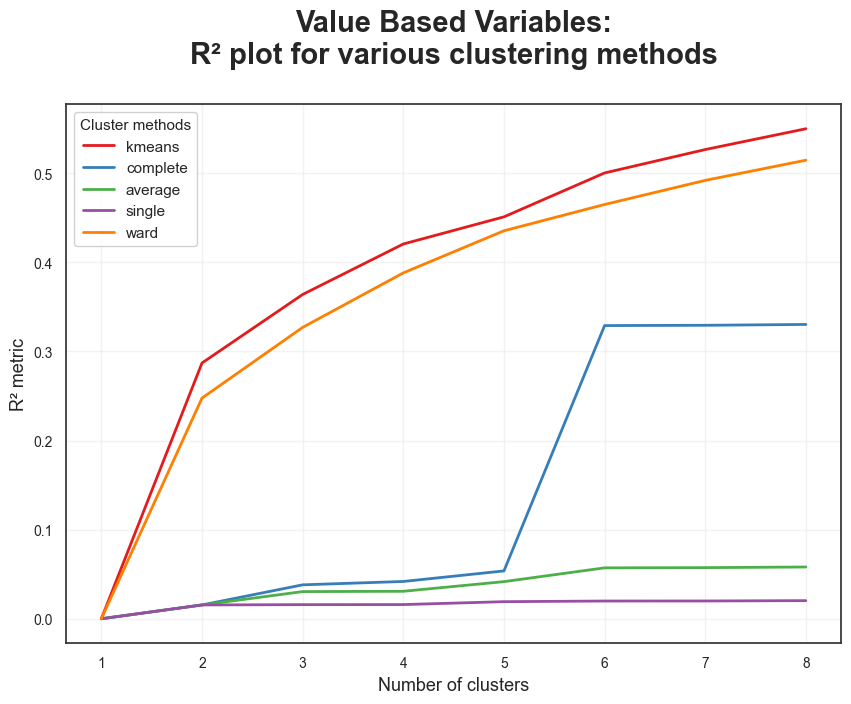

In [17]:
# Visualizing the R² scores for each cluster solution on value based variables
r2_scores_df.plot.line(figsize=(10,7))

plt.title("Value Based Variables:\nR² plot for various clustering methods\n", fontsize=21)
plt.legend(title="Cluster methods", title_fontsize=11)
plt.xlabel("Number of clusters", fontsize=13)
plt.ylabel("R² metric", fontsize=13)
plt.show()

## Silhouette Score Analysis <a id="silhouette-score-analysis"></a>

Calculating Silhouette Scores...
k=2: 0.3086
k=3: 0.1943
k=4: 0.2110
k=5: 0.2038
k=6: 0.2174
k=7: 0.1999
k=8: 0.2033
k=9: 0.1970
k=10: 0.1820
k=11: 0.1904
k=12: 0.1913
k=13: 0.1860
k=14: 0.1888


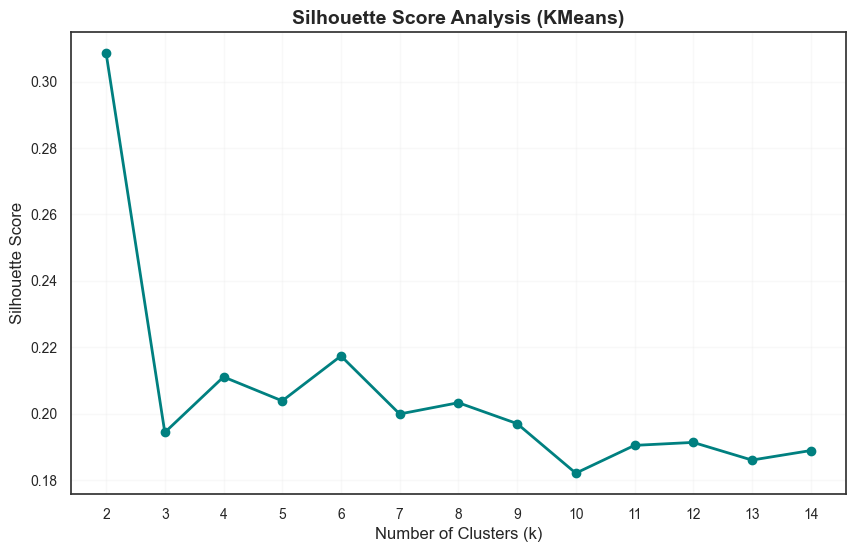

In [18]:
from sklearn.metrics import silhouette_score

silhouette_scores = {}
k_range = range(2, 15)  

print("Calculating Silhouette Scores...")

for k in k_range:
    # KMeans Parameter setzen
    kmeans.set_params(n_clusters=k, random_state=42)
    
    # Clustering durchführen
    labels = kmeans.fit_predict(df_value_based)
    
    # Score berechnen
    score = silhouette_score(df_value_based, labels)
    silhouette_scores[k] = score
    print(f"k={k}: {score:.4f}")



# Visualisierung
plt.figure(figsize=(10, 6))
pd.Series(silhouette_scores).plot(marker='o', color='teal')
plt.title('Silhouette Score Analysis (KMeans)', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()


We decide for a K=6 based on Silhouette Score Analysis and Elbow Method.

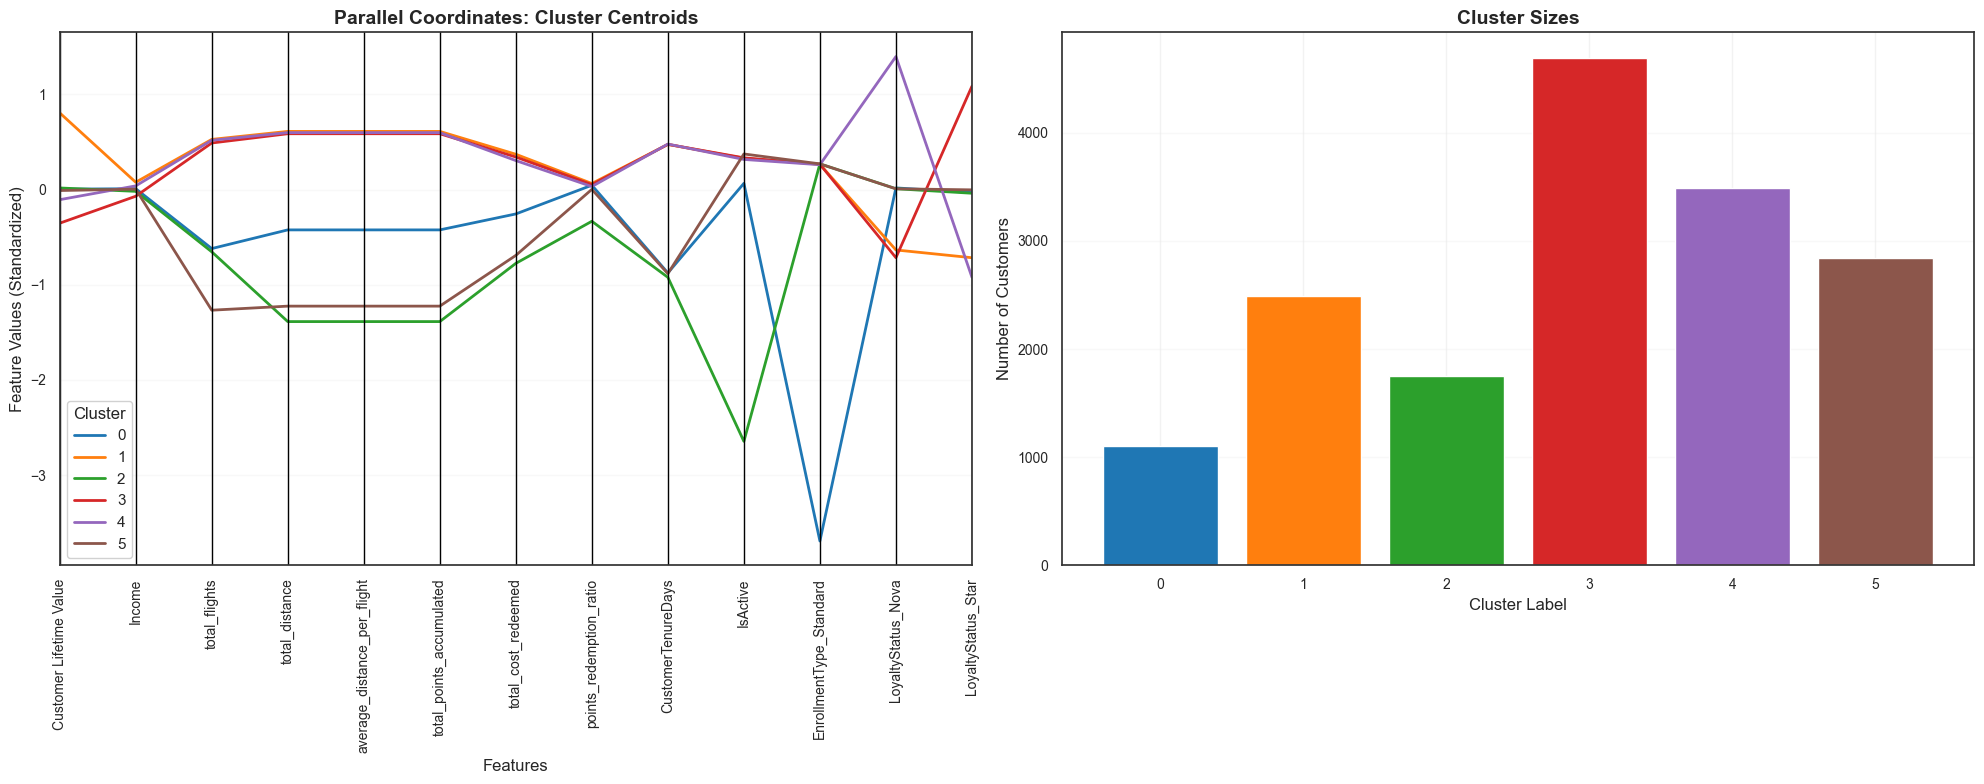

In [26]:
# 1. Finales Clustering durchführen 
k_best = 6
kmeans_final = KMeans(n_clusters=k_best, init='k-means++', n_init=20, random_state=42)
cluster_labels = kmeans_final.fit_predict(df_value_based)

# 2. DataFrame für Profiling vorbereiten
df_profile = df_value_based.copy()
df_profile['cluster'] = cluster_labels

# 3. Centroids berechnen (Durchschnittswerte pro Cluster)
df_centroids = df_profile.groupby('cluster')[value_based_features].mean()

# --- Visualisierung 1: Parallel Coordinates & Cluster Sizes ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# LEFT PLOT: Parallel coordinates
# Wir nutzen reset_index(), damit 'cluster' eine Spalte für die Färbung ist
pd.plotting.parallel_coordinates(
    df_centroids.reset_index(),
    'cluster',
    color=sns.color_palette('tab10', n_colors=k_best),
    ax=ax1
)
ax1.set_title('Parallel Coordinates: Cluster Centroids', fontsize=14, fontweight='bold')
ax1.set_ylabel('Feature Values (Standardized)', fontsize=12)
ax1.set_xlabel('Features', fontsize=12)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=90) # Labels drehen für Lesbarkeit
ax1.grid(True, alpha=0.3)
ax1.legend(title='Cluster', loc='best')

# RIGHT PLOT: Cluster sizes
cluster_sizes = df_profile['cluster'].value_counts().sort_index()
colors = sns.color_palette('tab10', n_colors=k_best)

ax2.bar(cluster_sizes.index.astype(str), cluster_sizes.values, color=colors)
ax2.set_xlabel('Cluster Label', fontsize=12)
ax2.set_ylabel('Number of Customers', fontsize=12)
ax2.set_title('Cluster Sizes', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

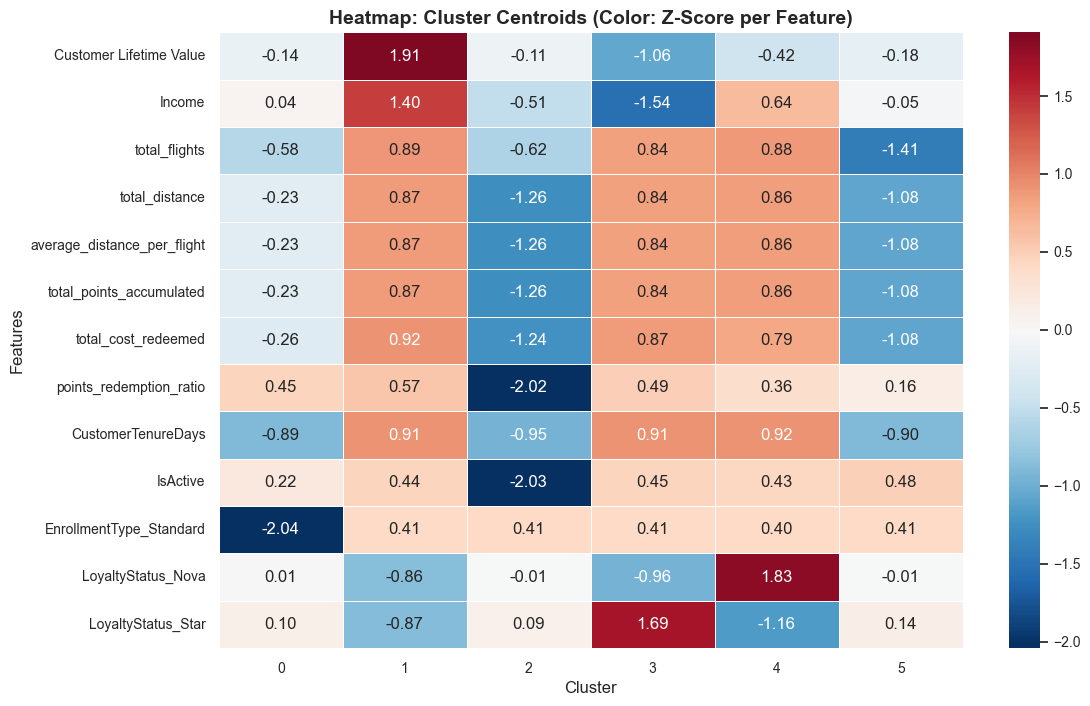

In [27]:
# --- Visualisierung 2: Heatmap der Centroids ---
plt.figure(figsize=(12, 8))

# Daten vorbereiten: Features als Zeilen
df_plot = df_centroids.T

# Standardisierung pro Feature (Zeile), damit die Farbskala unabhängig von der absoluten Höhe der Werte ist
# (Z-Score Normalisierung über die Cluster hinweg: (Wert - Mittelwert) / Standardabweichung)
df_plot_scaled = df_plot.apply(lambda x: (x - x.mean()) / x.std(), axis=1)

# Transponieren (T), damit Features auf der Y-Achse sind
sns.heatmap(
    df_plot_scaled, 
    cmap='RdBu_r',  # Rot-Blau Farbverlauf (gut für Abweichungen vom Mittelwert)
    center=0,       # Zentriert bei 0 (falls Daten standardisiert sind)
    annot=True,     # Werte anzeigen
    fmt='.2f',      # 2 Nachkommastellen
    linewidths=.5
)

plt.title('Heatmap: Cluster Centroids (Color: Z-Score per Feature)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

Number of customers in each cluster:
Cluster 0: 1104 customers
Cluster 1: 2495 customers
Cluster 2: 1753 customers
Cluster 3: 4695 customers
Cluster 4: 3487 customers
Cluster 5: 2841 customers


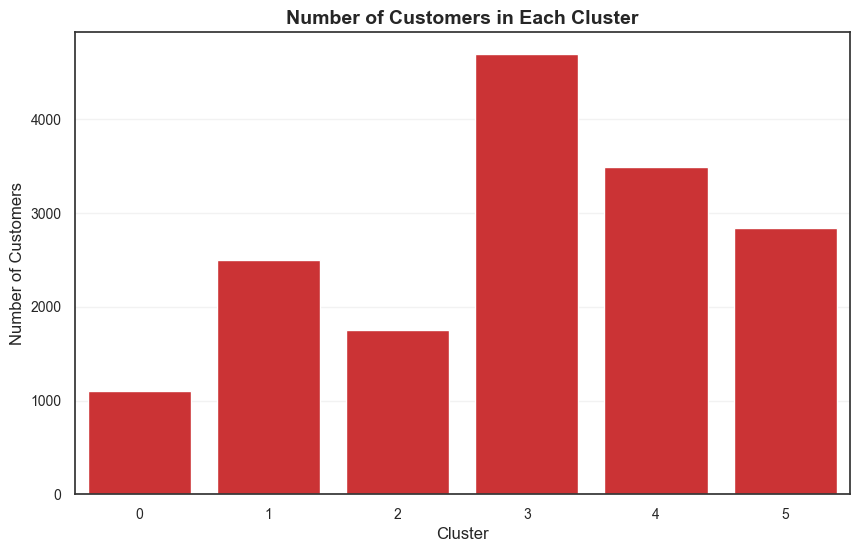

In [28]:
# Count the number of customers in each cluster and display the result and plot it
cluster_counts = df_profile['cluster'].value_counts().sort_index()
print("Number of customers in each cluster:")
for cluster_label, count in cluster_counts.items():
    print(f"Cluster {cluster_label}: {count} customers")

plt.figure(figsize=(10, 6))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values)
plt.title('Number of Customers in Each Cluster', fontsize=14)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.show()



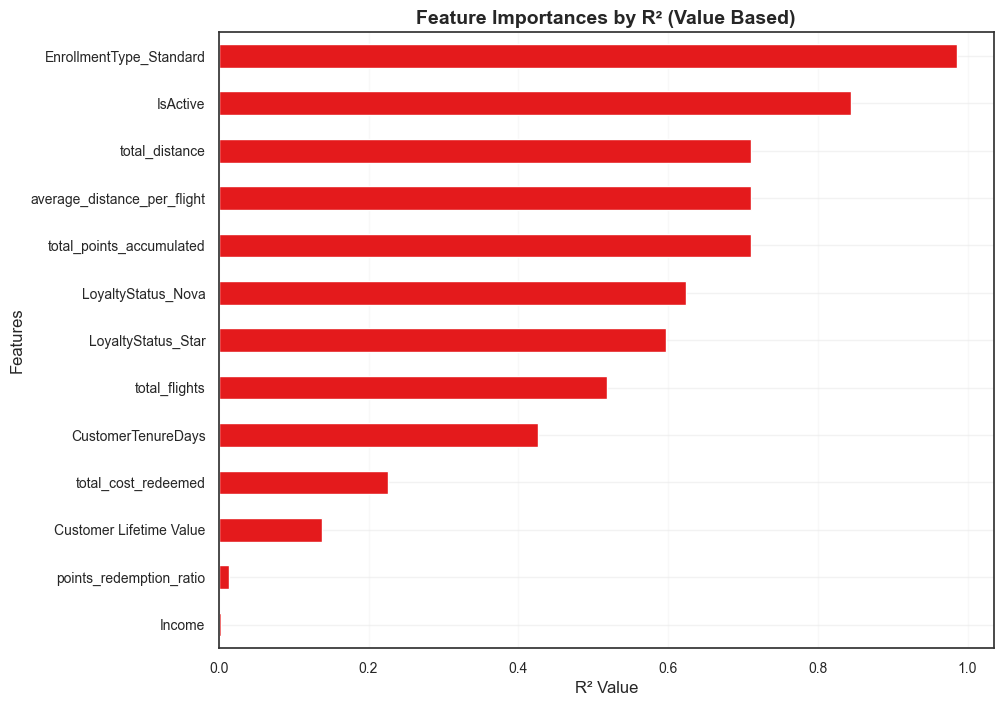

In [29]:
# Da 'r2_variables' nicht definiert ist, berechnen wir R2 für jedes Feature einzeln
# mit der existierenden 'get_rsq' Funktion.
r2_data = {}
for feature in value_based_features:
    # get_rsq erwartet eine Liste von Features, daher [feature]
    r2_data[feature] = get_rsq(df_profile, [feature], 'cluster')

r2_feats = pd.Series(r2_data)

# Plotten
r2_feats.sort_values().plot.barh(figsize=(10, 8))
plt.title("Feature Importances by R² (Value Based)", fontsize=14)
plt.xlabel("R² Value", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.show()

In [57]:
# Calculate R² for KMeans clustering
r2_km = get_rsq(df_profile, value_based_features, 'cluster')
print("R² for KMeans clustering:", r2_km)

R² for KMeans clustering: 0.500430056827565


# 2. Density Clustering - Value Based  <a class="anchor" id="data-validity-checks"></a>

We have done KMeans++ Clustering. Now we will do Density Based Clustering for Value Based Perspective. We will use DBSCAN and Mean Shift and GMM Algorithms for Density Based Clustering.

DBSCAN Algorithm:

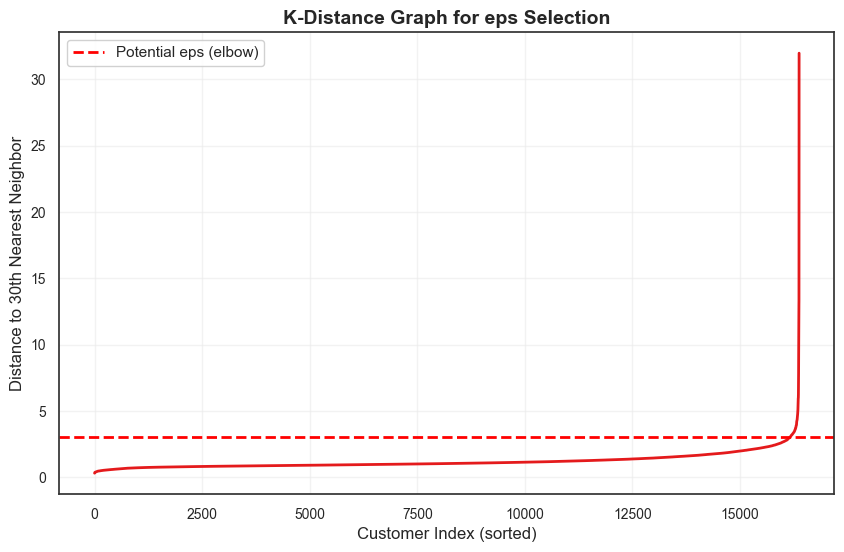

In [36]:
from sklearn.neighbors import NearestNeighbors


# Find optimal eps using K-distance method
neigh = NearestNeighbors(n_neighbors=30) # n_features * 2 as a rule of thumb
neigh.fit(df_value_based)
distances, indices = neigh.kneighbors(df_value_based)
# matrix of n_samples x n_neighbors nearest neighbors distances
distances = np.sort(distances[:, -1])  # sort by the 30th nearest neighbor
# distances for every sample to the 30th nearest neighbor, sorted

plt.figure(figsize=(10,6))
plt.plot(distances)
plt.title("K-Distance Graph for eps Selection")
plt.xlabel("Customer Index (sorted)")
plt.ylabel("Distance to 30th Nearest Neighbor")
plt.grid(True)

plt.axhline(y=3, color='r', linestyle='--', label='Potential eps (elbow)')

plt.legend()
plt.show()

In [39]:
# Perform DBSCAN clustering
dbscan = DBSCAN(eps=3, min_samples=30, n_jobs=-1)

dbscan_labels = dbscan.fit_predict(df_value_based)

print("DBSCAN found", len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0), "clusters")

DBSCAN found 4 clusters


In [40]:
np.unique(dbscan_labels)

array([-1,  0,  1,  2,  3])

In [42]:
df_concat = pd.concat([df_value_based,
                       pd.Series(dbscan_labels, name='dbscan_labels', index=df_value_based.index)], axis=1)

df_concat

,Customer Lifetime Value,Income,total_flights,total_distance,average_distance_per_flight,total_points_accumulated,total_cost_redeemed,points_redemption_ratio,CustomerTenureDays,IsActive,EnrollmentType_Standard,LoyaltyStatus_Nova,LoyaltyStatus_Star,dbscan_labels
0,-0.605614,1.068659,1.109748,1.338111,1.338112,1.338311,0.576033,-0.047634,-0.072878,0.378083,0.270829,-0.715057,1.086341,0
1,-0.605545,-1.243243,1.895346,0.843650,0.843651,0.843514,1.584071,0.584566,-0.102559,0.378083,0.270829,-0.715057,1.086341,0
2,-0.605524,-1.243243,-0.289489,-0.317820,-0.317819,-0.317841,-0.369294,-0.137006,0.229333,-2.644921,0.270829,-0.715057,1.086341,1
3,-0.605524,-1.243243,0.558533,0.592202,0.592203,0.592203,0.896561,0.333447,1.403096,0.378083,0.270829,-0.715057,1.086341,0
4,-0.605080,1.981146,0.449586,0.488742,0.488742,0.488700,-0.987124,-0.696816,0.572018,0.378083,-3.692371,-0.715057,1.086341,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16370,7.874405,-1.243243,0.113911,0.770363,0.770363,0.770479,-0.987124,-0.696816,1.479998,0.378083,0.270829,-0.715057,1.086341,-1
16371,8.759826,1.337732,1.542003,0.448107,0.448107,0.447844,0.902368,0.406936,0.638126,0.378083,0.270829,-0.715057,1.086341,-1
16372,9.683862,-1.243243,1.109748,1.210680,1.210681,1.210686,0.828042,0.090912,0.862086,0.378083,0.270829,-0.715057,1.086341,-1
16373,11.013635,0.699920,-1.579189,-1.400577,-1.400576,-1.400682,-0.383230,1.342012,-1.160295,-2.644921,-3.692371,-0.715057,1.086341,-1


In [43]:
df_concat['dbscan_labels'].value_counts().sort_index()

dbscan_labels
-1       59
 0    13288
 1     1924
 2      996
 3      108
Name: count, dtype: int64

In [45]:
r2_db = get_rsq(df_concat, value_based_features, 'dbscan_labels')
print("R² for DBSCAN clustering:", r2_db)

R² for DBSCAN clustering: 0.2470702389861927


Guassian Mixture Model (GMM) Algorithm:

### Defining n_components:

**AIC**: estimates the relative amount of information lost by a model used to represent the data-generation process. The smaller the better.

**BIC**: similar to AIC but penalizes more complex models (i.e. favors simpler models). The smaller the better.

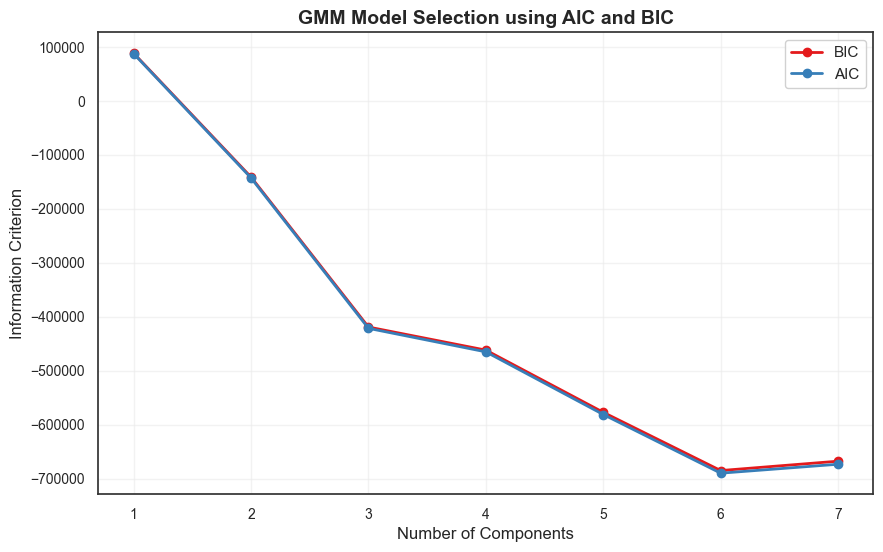

In [46]:
# Selecting number of components based on AIC and BIC
from sklearn.mixture import GaussianMixture

n_components = np.arange(1,8)

models = []
for n in n_components:
    gmm = GaussianMixture(n_components=n, covariance_type='full', random_state=42)
    gmm.fit(df_value_based)
    models.append(gmm)

bic_values = [m.bic(df_value_based) for m in models]
aic_values = [m.aic(df_value_based) for m in models]

plt.figure(figsize=(10,6))
plt.plot(n_components, bic_values, label='BIC', marker='o')
plt.plot(n_components, aic_values, label='AIC', marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Information Criterion')
plt.title('GMM Model Selection using AIC and BIC')
plt.xticks(n_components)
plt.legend()
plt.grid(True)
plt.show()

In [47]:
# Performing GMM clustering
gmm = GaussianMixture(n_components=3, covariance_type='full', n_init=10, init_params='kmeans', random_state=1)

gmm_labels = gmm.fit_predict(df_value_based)

In [ ]:
# Concatenating the labels to df
df_concat = pd.concat([df_value_based, pd.Series(gmm_labels, index=df_value_based.index, name="gmm_labels")], axis=1)

df_concat['gmm_labels'].value_counts().sort_index()

GMM R² score: 0.2435


In [56]:
r2_gmm = get_rsq(df_concat, value_based_features, 'gmm_labels')
print(f"GMM R² score: {r2_gmm:.4f}")

GMM R² score: 0.2435


Mean Shift Algorithm:

The `estimate_bandwidth()` function uses nearest neighbors to find optimal neighborhood size.

**How estimate_bandwidth works:**
1. Specify `quantile`: 
    - Determines `n_neighbors` to include when computing distances
2. For each points calculate `n_neighbors` nearest neighbors 
3. Get the largest distance to the `n_neighbors` 
3. Average of these largest distances 

In [93]:
# CORRECT approach - data-driven bandwidth
bandwidth = estimate_bandwidth(df_value_based, quantile=0.06, random_state=42)
print("Calculated bandwidth for Mean Shift:", bandwidth)

Calculated bandwidth for Mean Shift: 2.7714284839858205


In [94]:
from sklearn.cluster import MeanShift, estimate_bandwidth

# Apply Mean Shift with estimated bandwidth
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True, n_jobs=4)
    # bin_seeding=True for faster convergence (bins defined by bandwidth); default False, uses all points as seeds
    # n_jobs=4 to use 4 CPU cores for parallel processing; default is 1 (no parallelism)
ms_labels = ms.fit_predict(df_value_based)

In [95]:
n_clusters = len(np.unique(ms_labels))

print(pd.Series(ms_labels).value_counts().sort_index())

0     11363
1      3730
2       536
3       465
4       108
5        32
6         9
7        65
8        45
9        19
10        3
Name: count, dtype: int64


In [96]:
r2_mean_shift = get_rsq(df_value_based.assign(mean_shift_labels=ms_labels), value_based_features, 'mean_shift_labels')
print(f"Mean Shift R² score: {r2_mean_shift:.4f}")

Mean Shift R² score: 0.4082
